First Pipeline to run binding energy


In [2]:
!uv pip install fairchem-core

Using Python 3.13.11 environment at: C:\Users\miaom\miniconda3\envs\cms
Audited 1 package in 4.16s


In [3]:
# check through Hugging Face Hub if the package is installed correctly, paste result in chatgpt or claude to confirm
# you mainly need to check off " Read access to contents of all public gated repos you can access" and " Read access to contents of all private gated repos you can access" in tokens settings in Hugging Face Hub, and that the token is correctly set up in your environment variables
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '69d423a991dfba6b651bddfe', 'name': 'umami393', 'fullname': 'Margaret', 'isPro': False, 'avatarUrl': '/avatars/eb54fe80196fee8cdf7c5c7ace19b460.svg', 'orgs': [{'type': 'org', 'id': '64374111a701a7e744c02b0e', 'name': 'princetonu', 'fullname': 'Princeton University', 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/68e396f2b5bb631e9b2fac9a/b3xXusq8Zz3ej8Z6fRTSZ.png'}], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'Rep Perm', 'role': 'fineGrained', 'createdAt': '2026-04-06T21:24:55.150Z', 'fineGrained': {'canReadGatedRepos': False, 'global': [], 'scoped': [{'entity': {'_id': '67098f31ee3ea12411d3f44e', 'type': 'model', 'name': 'facebook/OMAT24'}, 'permissions': []}, {'entity': {'_id': '67f5bb06b8e3712b3da49bfc', 'type': 'model', 'name': 'facebook/UMA'}, 'permissions': []}, {'entity': {'_id': '69d423a991dfba6b651bddfe', 'type': 'user', 'name': 'umami393'}, 'permissions': ['repo.content.read']}]}}}}


In [4]:
from fairchem.core import pretrained_mlip

predictor = pretrained_mlip.get_predict_unit(
    model_name="uma-s-1p1",
    device="cpu"
)

W0410 11:08:07.931000 83400 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [5]:
# test with calculator 
from ase.build import bulk
from fairchem.core import pretrained_mlip, FAIRChemCalculator

device = "cpu"

atoms = bulk("Si")

model_name = "uma-s-1p1"
predictor = pretrained_mlip.get_predict_unit(model_name)
calc = FAIRChemCalculator(predictor, task_name="omat")

atoms.calc = calc
e = atoms.get_potential_energy()
print(e)



-10.82311692799609


In [6]:
from ase.io import read
from ase.build import molecule
from ase.optimize import BFGS

# -------------------------
# Load structures
# -------------------------
mof_74 = read("mg_mof74.cif")
co2 = molecule("CO2")

# -------------------------
# Assign calculator
# -------------------------
mof_74.calc = calc
co2.calc = calc

# -------------------------
# Relax MOF
# -------------------------
opt_mof = BFGS(mof_74, logfile="opt_mof_74.log")
opt_mof.run(fmax=0.01)

E_mof = mof_74.get_potential_energy()
print(f"E(Mg-MOF-74) = {E_mof:.6f} eV")

# Relax CO2
co2.center(vacuum=10.0)  # IMPORTANT (no periodic interactions)

opt_co2 = BFGS(co2, logfile="opt_co2.log")
opt_co2.run(fmax=0.01)

E_co2 = co2.get_potential_energy()
print(f"E(CO2, free) = {E_co2:.6f} eV")

E(Mg-MOF-74) = -1177.415280 eV
E(CO2, free) = -22.596883 eV


In [7]:
import numpy as np
# get indices of metal atoms (Mg)
metal_indices = [i for i, a in enumerate(mof_74) if a.symbol == "Mg"]
metal_positions = mof_74.positions[metal_indices]

In [8]:
# center of unit cell (cartesian)
cell_center = np.dot([0.5, 0.5, 0.5], mof_74.get_cell())

def get_direction(metal_pos):
    direction = cell_center - metal_pos
    return direction / np.linalg.norm(direction)

In [9]:
from ase.geometry import get_distances
import numpy as np

def is_valid_position_full(mof, co2, cutoff=1.6):
    dmat = get_distances(
        mof.positions,
        co2.positions,
        cell=mof.get_cell(),
        pbc=mof.get_pbc()
    )[1]
    return np.min(dmat) > cutoff

In [10]:
def get_directions():
    dirs = [
        [1,0,0], [-1,0,0],
        [0,1,0], [0,-1,0],
        [0,0,1], [0,0,-1]
    ]
    return [np.array(d)/np.linalg.norm(d) for d in dirs]

In [11]:
def place_co2_oriented(mof, co2, metal_index):
    metal_pos = mof.positions[metal_index]

    directions = get_directions()

    for direction in directions:

        for d_mg_o in np.linspace(2.2, 2.8, 7):

            co2_copy = co2.copy()

            # align CO2 axis
            co2_axis = co2_copy.positions[2] - co2_copy.positions[0]
            co2_axis /= np.linalg.norm(co2_axis)

            v = np.cross(co2_axis, direction)
            angle = np.degrees(np.arccos(np.clip(np.dot(co2_axis, direction), -1, 1)))

            if np.linalg.norm(v) > 1e-8:
                co2_copy.rotate(angle, v, center='COM')

            # place oxygen
            target = metal_pos + d_mg_o * direction
            shift = target - co2_copy.positions[0]
            co2_copy.positions += shift

            if is_valid_position_full(mof, co2_copy):

                metadata = {
                    "metal_index": metal_index,
                    "direction": direction,
                    "mg_o_distance": d_mg_o
                }

                return co2_copy, metadata

    return None, None

In [12]:
# combine system + computing binding energy 
def compute_binding_energy(mof, co2_placed):
    system = mof.copy()
    system += co2_placed

    system.calc = calc

    opt = BFGS(system, logfile=None)
    opt.run(fmax=0.05)

    E_total = system.get_potential_energy()

    return E_total - E_mof - E_co2

In [13]:
# testing only for one magnesium site first (we can loop over all sites later)
mg_idx = 14
print(f"Testing Mg site index: {mg_idx}, symbol = {mof_74[mg_idx].symbol}")

if mof_74[mg_idx].symbol != "Mg":
    raise ValueError(f"Atom index {mg_idx} is not Mg. It is {mof_74[mg_idx].symbol}.")

co2_placed, metadata = place_co2_oriented(mof_74, co2, mg_idx)  # unpack tuple

if co2_placed is None:
    raise RuntimeError("Could not place CO2 near Mg without overlap.")

print("CO2 placed successfully")


Testing Mg site index: 14, symbol = Mg
CO2 placed successfully


In [21]:
from ase.io import read, write

# intialize combined system for inspection before relaxation
system = mof_74.copy()
system += co2_placed
system.calc = calc

# inspect Mg-O distances before relaxation
print("Initial Mg–O distances:")
for j in range(len(mof_74), len(system)):
    if system[j].symbol == "O":
        d = system.get_distance(mg_idx, j, mic=True)
        print(d)


# -------------------------
# Relax combined system
# -------------------------
opt_system = BFGS(system, logfile="opt_single_site.log")
opt_system.run(fmax=0.05)

E_total = system.get_potential_energy()
E_bind = E_total - E_mof - E_co2

print(f"E(total)   = {E_total:.6f} eV")
print(f"E(bind)    = {E_bind:.6f} eV")

# -------------------------
# Inspect Mg-O distances after relaxation
# -------------------------
co2_start = len(mof_74)
for j in range(co2_start, len(system)):
    if system[j].symbol == "O":
        d = system.get_distance(mg_idx, j, mic=True)
        print(f"Mg-O distance to O atom {j}: {d:.3f} Å")



Initial Mg–O distances:
1.6197117768940383
3.9802788340625193
E(total)   = -1200.535052 eV
E(bind)    = -0.522828 eV
Mg-O distance to O atom 163: 2.369 Å
Mg-O distance to O atom 164: 4.411 Å


In [14]:
from ase.visualize import view

view(system)

NameError: name 'system' is not defined

In [15]:
# time to iterate across 3-4 sites 
metal_indices = [i for i, a in enumerate(mof_74) if a.symbol == "Mg"]

# pick first 4 for now
# 
test_sites = metal_indices # [:4]

print(f"Testing {len(test_sites)} Mg sites:", test_sites)

Testing 18 Mg sites: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


In [16]:
from ase.visualize import view

for idx in test_sites:
    co2_placed, meta = place_co2_oriented(mof_74, co2, idx)

    if co2_placed is None:
        print(f"Site {idx}: placement failed")
        continue

    system = mof_74.copy()
    system += co2_placed

    print(f"Viewing site {idx}")
    print("Direction:", meta["direction"])
    print("Mg-O distance:", meta["mg_o_distance"])

    view(system)
    input("Press Enter to continue...") # remember to do this lol

Viewing site 0
Direction: [-1.  0.  0.]
Mg-O distance: 2.8
Viewing site 1
Direction: [ 0. -1.  0.]
Mg-O distance: 2.8
Viewing site 2
Direction: [0. 1. 0.]
Mg-O distance: 2.8
Viewing site 3
Direction: [1. 0. 0.]
Mg-O distance: 2.8
Viewing site 4
Direction: [0. 1. 0.]
Mg-O distance: 2.8
Viewing site 5
Direction: [ 0. -1.  0.]
Mg-O distance: 2.8
Viewing site 6
Direction: [-1.  0.  0.]
Mg-O distance: 2.8
Viewing site 7
Direction: [ 0. -1.  0.]
Mg-O distance: 2.8
Viewing site 8
Direction: [0. 1. 0.]
Mg-O distance: 2.8
Viewing site 9
Direction: [1. 0. 0.]
Mg-O distance: 2.8
Viewing site 10
Direction: [0. 1. 0.]
Mg-O distance: 2.8
Viewing site 11
Direction: [ 0. -1.  0.]
Mg-O distance: 2.8
Viewing site 12
Direction: [-1.  0.  0.]
Mg-O distance: 2.8
Viewing site 13
Direction: [ 0. -1.  0.]
Mg-O distance: 2.8
Viewing site 14
Direction: [0. 1. 0.]
Mg-O distance: 2.8
Viewing site 15
Direction: [1. 0. 0.]
Mg-O distance: 2.8
Viewing site 16
Direction: [0. 1. 0.]
Mg-O distance: 2.8
Viewing site 17
D

In [17]:
results = []

for idx in test_sites:

    co2_placed, meta = place_co2_oriented(mof_74, co2, idx)

    if co2_placed is None:
        print(f"Site {idx}: placement failed")
        continue

    print(f"\nSite {idx}")
    print("Start Mg-O distance:", meta["mg_o_distance"])
    print("Direction:", meta["direction"])

    # build system
    system = mof_74.copy()
    system += co2_placed
    system.calc = calc

    co2_start = len(mof_74)
    start_dist = system.get_distance(idx, co2_start, mic=True)

    # relax
    opt = BFGS(system, logfile=None)
    opt.run(fmax=0.05)

    # find closest O in CO2 to Mg after relaxation (CO2 may have flipped)
    o_distances = {}
    for j in range(co2_start, len(system)):
        if system[j].symbol == "O":
            d = system.get_distance(idx, j, mic=True)
            o_distances[j] = d
            print(f"  O atom {j}: Mg-O = {d:.3f} Å")

    closest_o_idx = min(o_distances, key=o_distances.get)
    final_mg_o_dist = o_distances[closest_o_idx]

    # energies
    E_total = system.get_potential_energy()
    E_bind = E_total - E_mof - E_co2

    print(f"Final Mg-O distance (closest O, atom {closest_o_idx}): {final_mg_o_dist:.3f} Å")
    print("E_bind:", E_bind)

    results.append({
        "site": idx,
        "E_bind": E_bind,
        "direction": meta["direction"],
        "distance": meta["mg_o_distance"],
        "start_dist": start_dist,
        "final_mg_o_dist": final_mg_o_dist,
    })


Site 0
Start Mg-O distance: 2.8
Direction: [-1.  0.  0.]
  O atom 163: Mg-O = 2.346 Å
  O atom 164: Mg-O = 4.389 Å
Final Mg-O distance (closest O, atom 163): 2.346 Å
E_bind: -0.5518497228622365

Site 1
Start Mg-O distance: 2.8
Direction: [ 0. -1.  0.]
  O atom 163: Mg-O = 2.341 Å
  O atom 164: Mg-O = 4.189 Å
Final Mg-O distance (closest O, atom 163): 2.341 Å
E_bind: -0.566299796104424

Site 2
Start Mg-O distance: 2.8
Direction: [0. 1. 0.]
  O atom 163: Mg-O = 2.369 Å
  O atom 164: Mg-O = 4.411 Å
Final Mg-O distance (closest O, atom 163): 2.369 Å
E_bind: -0.522873282432549

Site 3
Start Mg-O distance: 2.8
Direction: [1. 0. 0.]
  O atom 163: Mg-O = 2.340 Å
  O atom 164: Mg-O = 4.384 Å
Final Mg-O distance (closest O, atom 163): 2.340 Å
E_bind: -0.562027335166924

Site 4
Start Mg-O distance: 2.8
Direction: [0. 1. 0.]
  O atom 163: Mg-O = 2.340 Å
  O atom 164: Mg-O = 4.205 Å
Final Mg-O distance (closest O, atom 163): 2.340 Å
E_bind: -0.570541739463799

Site 5
Start Mg-O distance: 2.8
Direc

In [18]:
# view results arra
for r in results:
    print(f"Site {r['site']}: E_bind = {r['E_bind']:.3f} eV, direction = {r['direction']}, distance = {r['final_mg_o_dist']:.2f} Å")

# break them into their own arrays for plotting
sites = [r["site"] for r in results]        
E_bind = [r["E_bind"] for r in results]
dist = [r["final_mg_o_dist"] for r in results]






Site 0: E_bind = -0.552 eV, direction = [-1.  0.  0.], distance = 2.35 Å
Site 1: E_bind = -0.566 eV, direction = [ 0. -1.  0.], distance = 2.34 Å
Site 2: E_bind = -0.523 eV, direction = [0. 1. 0.], distance = 2.37 Å
Site 3: E_bind = -0.562 eV, direction = [1. 0. 0.], distance = 2.34 Å
Site 4: E_bind = -0.571 eV, direction = [0. 1. 0.], distance = 2.34 Å
Site 5: E_bind = -0.528 eV, direction = [ 0. -1.  0.], distance = 2.36 Å
Site 6: E_bind = -0.552 eV, direction = [-1.  0.  0.], distance = 2.35 Å
Site 7: E_bind = -0.566 eV, direction = [ 0. -1.  0.], distance = 2.34 Å
Site 8: E_bind = -0.523 eV, direction = [0. 1. 0.], distance = 2.37 Å
Site 9: E_bind = -0.562 eV, direction = [1. 0. 0.], distance = 2.34 Å
Site 10: E_bind = -0.571 eV, direction = [0. 1. 0.], distance = 2.34 Å
Site 11: E_bind = -0.528 eV, direction = [ 0. -1.  0.], distance = 2.36 Å
Site 12: E_bind = -0.552 eV, direction = [-1.  0.  0.], distance = 2.35 Å
Site 13: E_bind = -0.566 eV, direction = [ 0. -1.  0.], distance =

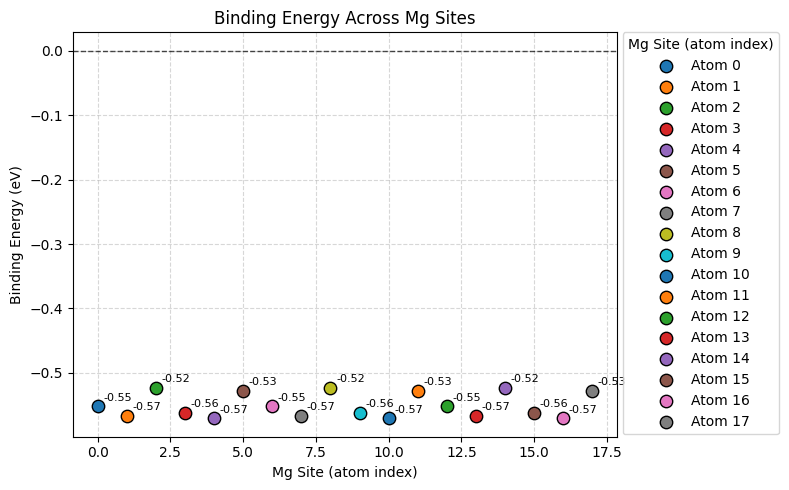

In [19]:
import matplotlib.pyplot as plt
from datetime import datetime

# binding energy plot vs. site index
fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.cm.tab10.colors

for i, (site_idx, e) in enumerate(zip(test_sites, E_bind)):
    ax.scatter(site_idx, e, color=colors[i % 10], edgecolors='black',
               zorder=3, label=f"Atom {site_idx}", s=80)
    ax.annotate(
        f"{e:.2f}",
        xy=(site_idx, e),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8,
    )

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)

ax.set_xlabel("Mg Site (atom index)")
ax.set_ylabel("Binding Energy (eV)")
ax.set_title("Binding Energy Across Mg Sites")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Mg Site (atom index)", bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f"binding_energy_across_sites_{timestamp}.png", dpi=150, bbox_inches='tight')
plt.show()

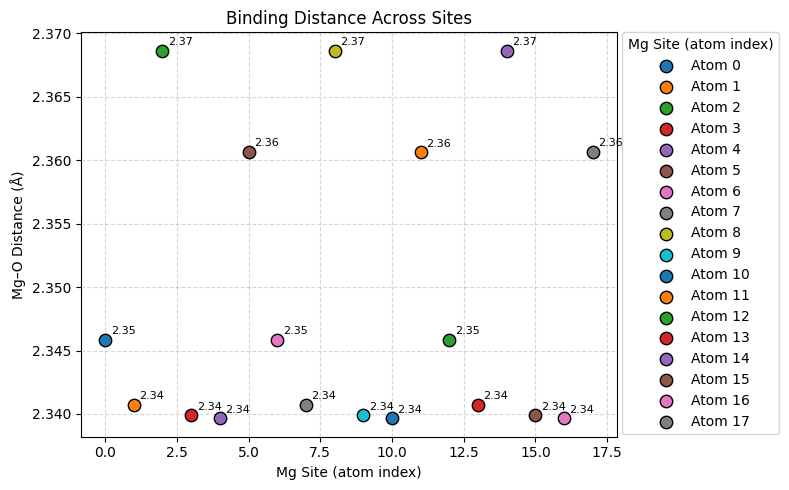

In [20]:
# Binding distance across sites
fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.cm.tab10.colors

for i, (site_idx, d) in enumerate(zip(test_sites, dist)):
    ax.scatter(site_idx, d, color=colors[i % 10], edgecolors='black',
               zorder=3, label=f"Atom {site_idx}", s=80)
    ax.annotate(
        f"{d:.2f}",
        xy=(site_idx, d),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8,
    )

ax.set_xlabel("Mg Site (atom index)")
ax.set_ylabel("Mg–O Distance (Å)")
ax.set_title("Binding Distance Across Sites")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Mg Site (atom index)", bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f"binding_distance_across_sites_{timestamp}.png", dpi=150, bbox_inches='tight')
plt.show()

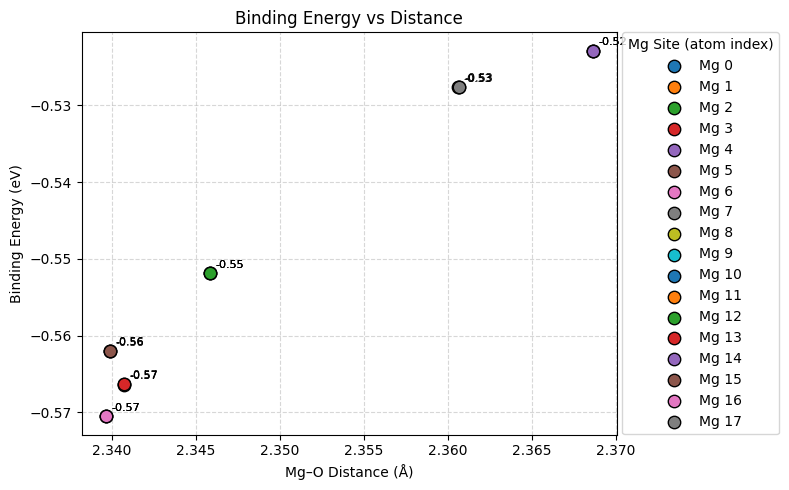

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.cm.tab10.colors

for i, (site_idx, d, e) in enumerate(zip(test_sites, dist, E_bind)):
    ax.scatter(d, e, color=colors[i % 10], edgecolors='black',
               zorder=3, label=f"Mg {site_idx}", s=80)
    ax.annotate(
        f"{e:.2f}",
        xy=(d, e),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8,
    )

ax.set_xlabel("Mg–O Distance (Å)")
ax.set_ylabel("Binding Energy (eV)")
ax.set_title("Binding Energy vs Distance")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Mg Site (atom index)", bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f"binding_energy_vs_distance_{timestamp}.png", dpi=150, bbox_inches='tight')
plt.show()

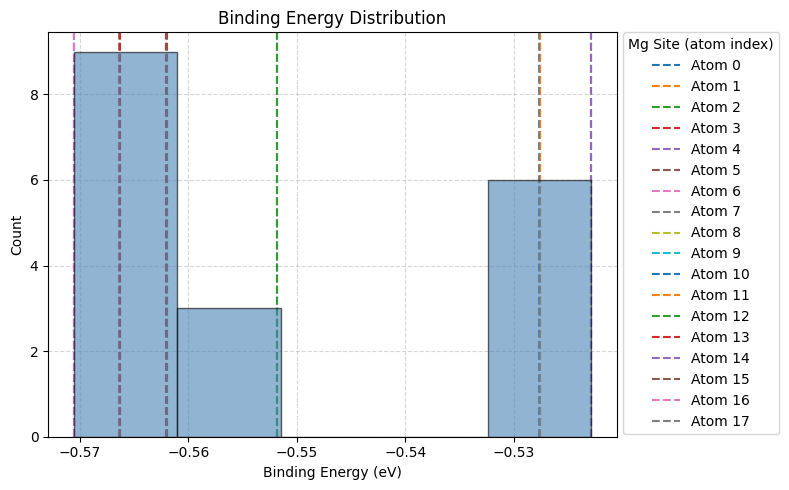

In [22]:
# binding energy distribution 
fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.cm.tab10.colors

for i, (site_idx, e) in enumerate(zip(test_sites, E_bind)):
    ax.axvline(e, color=colors[i % 10], linestyle='--', linewidth=1.5, label=f"Atom {site_idx}")

ax.hist(E_bind, bins=5, color='steelblue', edgecolor='black', alpha=0.6, zorder=2)

ax.set_xlabel("Binding Energy (eV)")
ax.set_ylabel("Count")
ax.set_title("Binding Energy Distribution")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Mg Site (atom index)", bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f"binding_energy_distribution_{timestamp}.png", dpi=150, bbox_inches='tight')
plt.show()

In [23]:
import json
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"results_{timestamp}.txt"

for r in results:
    r["direction"] = r["direction"].tolist()

with open(filename, "w") as f:
    json.dump(results, f, indent=2)

print(f"Saved to {filename}")

Saved to results_20260410_143837.txt
